## Case Study

### **Task 1**

Download the **“4000 series operating data”** and **“4000 series product data”** and become familiar with their structures.

**Refer_to_explortaory data Anaysis for now**

### **Task 2**

Compute the **product rate** for each batch using the following formula:

$$
\text{Product Rate (kg/hr)} =
\text{mean product (g/L)} \times
\text{mean total liquid inflow rate (L/hr)} \times 0.001
$$

where the **total liquid inflow rate** is defined as:

$$
\text{Total liquid inflow} =
\sum_{i=1}^{6} \text{liquid inflow}_i
$$

In [35]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

In [36]:
import pandas as pd
import sklearn
import numpy as np
print("All good")

All good


In [37]:
from applied.data_processing import load_operating_data
print("import ok")

import ok


In [38]:
import openpyxl
print("openpyxl ok")


openpyxl ok


In [39]:
from applied.data_processing import (
    load_operating_data,
    load_product_data,
    build_features_and_target,
)

from pathlib import Path
import pandas as pd

# Project root = one level above notebooks/
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

In [40]:
op_df

,Date and time,Batch,LIQUID,LIQUID.1,LIQUID.2,LIQUID.3,LIQUID.4,LIQUID.5,pH,GAS,GAS.1,GAS.2,GAS.3,OFFGAS,OFFGAS.1,PRESSURE,PRESSURE.1,OXYGEN
2,2019-02-04 08:46:00,4030,1049.57,25.91,14.44,NaN,297.73,14980.0,5.76,NaN,NaN,NaN,55.14,1.87,16.94,1.79,5.15,6.78
3,2019-02-04 09:01:00,4030,1049.09,25.62,13.54,NaN,357.44,15000.0,5.79,NaN,NaN,NaN,56.88,1.89,20.52,1.80,5.16,8.39
4,2019-02-04 09:16:00,4030,1049.61,25.44,13.59,NaN,356.83,15010.0,5.80,NaN,NaN,NaN,56.03,1.94,23.77,1.80,5.15,8.07
5,2019-02-04 09:31:00,4030,1047.57,25.59,13.97,NaN,356.77,15000.0,5.79,NaN,NaN,NaN,53.91,2.00,27.01,1.80,5.15,7.23
6,2019-02-04 09:46:00,4030,1048.16,25.49,13.43,NaN,357.21,15010.0,5.78,NaN,NaN,NaN,53.97,2.05,30.15,1.80,5.13,7.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83201,2021-05-25 21:15:00,4053,889.62,0.02,0.01,0.0,0.14,12910.0,5.83,11668.37,33.20,39.50,0.00,0.72,4.46,2.00,5.11,113.78
83202,2021-05-25 21:20:00,4053,888.61,0.02,0.01,0.0,0.07,20210.0,5.72,11283.46,29.42,34.63,0.00,0.68,4.43,1.99,5.09,114.99
83203,2021-05-25 21:25:00,4053,890.29,0.02,0.01,0.0,0.09,20950.0,5.62,10838.39,26.67,30.97,0.00,0.65,4.49,1.99,5.07,115.00
83204,2021-05-25 21:30:00,4053,878.23,0.02,0.01,0.0,0.14,20960.0,5.53,10510.03,24.30,27.70,0.00,0.63,4.48,2.00,5.04,115.00


In [41]:
# 1) Define liquid inflow columns
liquid_cols = [
    "LIQUID", "LIQUID.1", "LIQUID.2",
    "LIQUID.3", "LIQUID.4", "LIQUID.5"
]

# 2) Compute total liquid inflow per time point (L/hr)
op_df["total_liquid_inflow"] = op_df[liquid_cols].sum(axis=1, skipna=True)

# 3) Compute mean total liquid inflow per batch
mean_liquid_by_batch = (
    op_df
    .groupby("Batch", sort=False)["total_liquid_inflow"]
    .mean()
    .rename("mean_total_liquid")
)

# 4) Compute mean product concentration per batch (g/L)
mean_product_by_batch = (
    prod_df
    .groupby("Batch", sort=False)["Product"]
    .mean()
    .rename("mean_product")
)

# 5) Combine batch-level summaries
batch_summary = pd.concat(
    [mean_product_by_batch, mean_liquid_by_batch],
    axis=1
)

# 6) Compute product rate (kg/hr)
batch_summary["product_rate_kg_hr"] = (
    batch_summary["mean_product"]
    * batch_summary["mean_total_liquid"]
    * 0.001
)

# 7) Display result
batch_summary.head()

,mean_product,mean_total_liquid,product_rate_kg_hr
Batch,,,
4030,24.511466,25143.546281,616.305179
4032,24.623969,25225.945362,621.162886
4033,24.800353,24550.828963,608.869223
4034,25.052205,24835.980215,622.196071
4035,24.647115,24603.973947,606.416985


In [42]:
prod_df

,Date and time,Batch,Product
2,2019-02-04 00:00:00,4030,5.90
3,2019-02-04 02:00:00,4030,8.20
4,2019-02-04 04:00:00,4030,9.70
5,2019-02-04 06:00:00,4030,14.30
6,2019-02-04 08:00:00,4030,16.40
...,...,...,...
3216,2021-04-09 20:00:00,4052,27.36
3217,2021-04-10 00:00:00,4052,27.00
3218,2021-04-10 04:00:00,4052,25.10
3219,2021-04-10 08:00:00,4052,26.00


### **Task 3**

Using the computed product rates, **rank the productivity of the batches**.  
The product rate is a valid comparison metric across batches and is **independent of batch duration**, which is highly variable.

In [43]:
# 1) Rank batches by product rate (highest = most productive)
batch_ranking = (
    batch_summary
    .sort_values("product_rate_kg_hr", ascending=False)
    .assign(productivity_rank=lambda df: range(1, len(df) + 1))
)

# 2) Display ranked table
batch_ranking

,mean_product,mean_total_liquid,product_rate_kg_hr,productivity_rank
Batch,,,,
4041,27.263270,24583.602688,670.229408,1
4043,27.041068,24753.736520,669.367477,2
4047,26.370833,25144.553486,663.082829,3
4040,26.450455,24623.509532,651.303020,4
4042,26.367835,24493.636569,645.844169,5
4046,26.017734,24782.597009,644.787017,6
4045,26.591552,24100.309285,640.864621,7
4052,25.787324,24405.554019,629.353928,8
4034,25.052205,24835.980215,622.196071,9


### **Task 4**

Use **machine learning procedures** to identify the **process parameters most clearly related to product rate variability**.

In [44]:
X, y = build_features_and_target(op_df, prod_df)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Feature matrix shape: (22, 17)
Target shape: (22,)


,LIQUID_mean,LIQUID.1_mean,LIQUID.2_mean,LIQUID.3_mean,LIQUID.4_mean,LIQUID.5_mean,pH_mean,GAS_mean,GAS.1_mean,GAS.2_mean,GAS.3_mean,OFFGAS_mean,OFFGAS.1_mean,PRESSURE_mean,PRESSURE.1_mean,OXYGEN_mean,total_liquid_inflow_mean
Batch,,,,,,,,,,,,,,,,,
4030,1182.324976,34.722537,18.810690,39.050806,496.263217,23407.482905,5.701843,10244.155514,NaN,NaN,109.610918,2.840029,1.334083,1.986770,5.274894,20.290922,25143.546281
4032,1184.364106,32.586095,17.738195,41.385911,463.319444,23486.551611,5.752268,9294.441529,54.824528,54.065306,118.538008,3.288047,1.950243,1.912288,5.156532,22.220957,25225.945362
4033,1164.284559,34.228293,18.433985,44.179456,486.013781,22803.688889,5.660681,9598.216726,54.888511,54.886207,116.023111,4.091463,4.713211,1.966133,5.178363,22.541796,24550.828963
4034,1179.522407,35.252449,19.028614,45.465295,499.846881,23056.864570,5.993883,9203.138521,54.787734,54.780356,117.980254,3.917763,4.507535,1.992551,5.245424,14.902031,24835.980215
4035,1171.137963,34.919511,18.806442,44.992346,494.881918,22839.235766,5.640921,9185.096114,54.876106,54.870890,114.965166,3.933428,5.430692,1.995197,5.195113,17.189599,24603.973947


Batch
4030    616.305179
4032    621.162886
4033    608.869223
4034    622.196071
4035    606.416985
Name: product_rate, dtype: float64

In [46]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# remove rows where target is NaN
mask = ~np.isnan(y)
X = X[mask]
y = y[mask]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )),
    ]),
}

for name, model in models.items():
    rmse = -cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=cv
    ).mean()
    
    print(f"{name}: mean RMSE = {rmse:.4f}")

Ridge: mean RMSE = 18.8611
RandomForest: mean RMSE = 20.1137


In [47]:
print("NaNs in y:", y.isna().sum())
print("Total samples:", len(y))

NaNs in y: 0
Total samples: 21


In [48]:
# Combine X and y temporarily for cleaning
data = X.copy()
data["target"] = y

# Drop rows where target is missing
data = data.dropna(subset=["target"])

# Separate again
X_clean = data.drop(columns=["target"])
y_clean = data["target"]

print("After cleaning:")
print("Samples:", len(y_clean))
print("Remaining NaNs in y:", y_clean.isna().sum())

After cleaning:
Samples: 21
Remaining NaNs in y: 0


In [49]:
print(X_clean.columns)

Index(['LIQUID_mean', 'LIQUID.1_mean', 'LIQUID.2_mean', 'LIQUID.3_mean',
       'LIQUID.4_mean', 'LIQUID.5_mean', 'pH_mean', 'GAS_mean', 'GAS.1_mean',
       'GAS.2_mean', 'GAS.3_mean', 'OFFGAS_mean', 'OFFGAS.1_mean',
       'PRESSURE_mean', 'PRESSURE.1_mean', 'OXYGEN_mean',
       'total_liquid_inflow_mean'],
      dtype='object')


In [50]:
for name, model in models.items():
    rmse = -cross_val_score(
        model,
        X_clean,
        y_clean,
        scoring="neg_root_mean_squared_error",
        cv=cv
    ).mean()
    print(f"{name}: mean RMSE = {rmse:.4f}")

Ridge: mean RMSE = 18.8611
RandomForest: mean RMSE = 20.1137


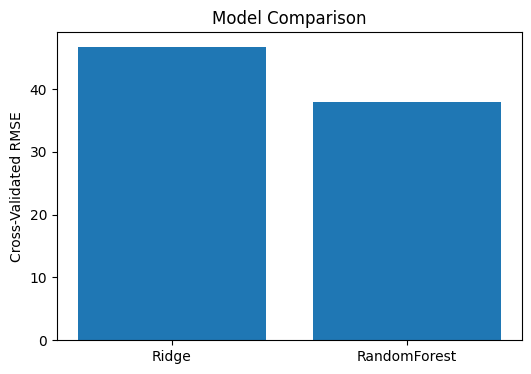

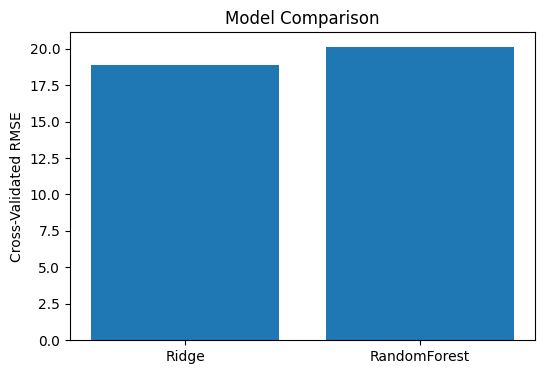

In [52]:
import matplotlib.pyplot as plt

results = {
    "Ridge": 46.6958,
    "RandomForest": 37.9503
}

plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values())
plt.ylabel("Cross-Validated RMSE")
plt.title("Model Comparison")
plt.show()

rmse_values = []

for name, model in models.items():
    rmse = -cross_val_score(
        model,
        X_clean,
        y_clean,
        scoring="neg_root_mean_squared_error",
        cv=cv
    ).mean()
    rmse_values.append(rmse)

plt.figure(figsize=(6,4))
plt.bar(models.keys(), rmse_values)
plt.ylabel("Cross-Validated RMSE")
plt.title("Model Comparison")
plt.show()

In [53]:
from sklearn.inspection import permutation_importance
import pandas as pd

rf = models["RandomForest"]
rf.fit(X_clean, y_clean)

perm = permutation_importance(
    rf,
    X_clean,
    y_clean,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    perm.importances_mean,
    index=X_clean.columns
).sort_values(ascending=False)

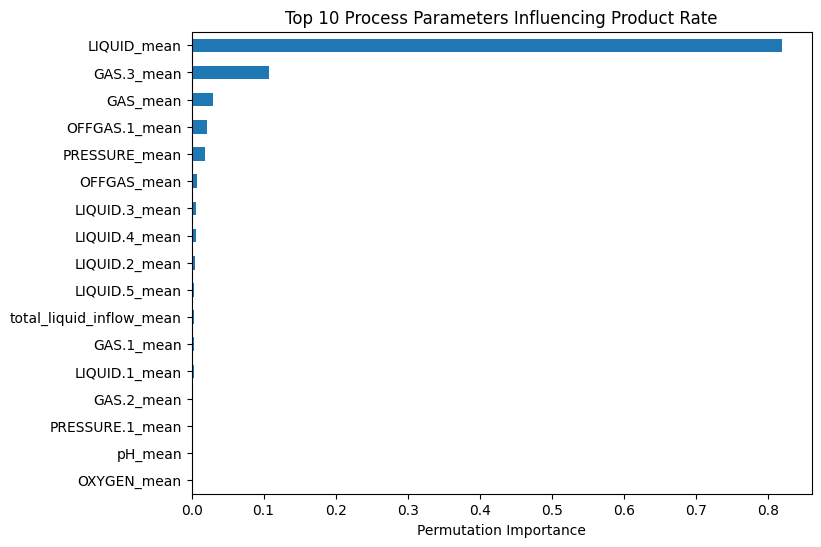

In [54]:
top10 = importance.head(50)

plt.figure(figsize=(8,6))
top10.sort_values().plot(kind="barh")
plt.xlabel("Permutation Importance")
plt.title("Top 10 Process Parameters Influencing Product Rate")
plt.show()

In [108]:
def correlation_report(X, y=None, threshold=0.75, mode="both"):
    """
    Correlation diagnostics.

    Parameters
    ----------
    X : pandas.DataFrame
        Feature matrix
    y : pandas.Series or array-like, optional
        Target variable
    threshold : float
        Minimum absolute correlation to report
    mode : {"feature", "target", "duplicates", "both"}
        feature     → X vs X correlations
        target      → X vs y correlations
        duplicates  → duplicate feature detection
        both        → feature + target correlations

    Returns
    -------
    Depending on mode:
        feature_corr_df
        target_corr_df
        duplicate_features
    """

    import numpy as np
    import pandas as pd

    X = X.copy()

    feature_corr_df = None
    target_corr_df = None
    duplicate_features = None

    # -----------------------------
    # Duplicate features
    # -----------------------------
    if mode in ["duplicates", "both"]:
        duplicate_cols = X.T.duplicated()
        duplicate_features = X.columns[duplicate_cols].tolist()

    # -----------------------------
    # Feature vs Feature
    # -----------------------------
    if mode in ["feature", "both"]:

        corr_matrix = X.corr().abs()

        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        feature_pairs = [
            (idx, col, upper_triangle.loc[idx, col])
            for col in upper_triangle.columns
            for idx in upper_triangle.index
            if upper_triangle.loc[idx, col] > threshold
        ]

        feature_corr_df = (
            pd.DataFrame(feature_pairs, columns=["Feature_1", "Feature_2", "Correlation"])
            .sort_values("Correlation", ascending=False)
            .reset_index(drop=True)
        )

    # -----------------------------
    # Feature vs Target
    # -----------------------------
    if y is not None and mode in ["target", "both"]:

        target_corr = X.corrwith(y).abs()

        target_corr_df = (
            target_corr[target_corr > threshold]
            .sort_values(ascending=False)
            .reset_index()
        )

        target_corr_df.columns = ["Feature", "Correlation_with_Target"]

    # -----------------------------
    # Return depending on mode
    # -----------------------------
    if mode == "feature":
        return feature_corr_df

    if mode == "target":
        return target_corr_df

    if mode == "duplicates":
        return duplicate_features

    return feature_corr_df, target_corr_df, duplicate_features

In [109]:
feature_corr = correlation_report(X_clean, threshold=0.8, mode="feature")
target_corr = correlation_report(X_clean, y, threshold=0.7, mode="target")

feature_corr

,Feature_1,Feature_2,Correlation
0,LIQUID.1_mean,LIQUID.4_mean,0.979335
1,LIQUID_mean,GAS.3_mean,0.892790


In [105]:
target_corr

,Feature,Correlation_with_Target
0,LIQUID_mean,0.948973
1,GAS.3_mean,0.867120


In [116]:
features = target_corr["Feature"].tolist()
features

['LIQUID_mean', 'GAS.3_mean']

In [110]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,8))
# sns.heatmap(X_clean.corr(), cmap="coolwarm", center=0)
# plt.title("Feature Correlation Matrix")
# plt.show()

In [111]:
rf = models["RandomForest"]
rf.fit(X_clean, y_clean)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,500


Task 4 – Identification of Key Drivers of Product Rate Variability

Cross-validated model comparison demonstrated that a Random Forest regressor (RMSE ≈ 38) outperformed a linear Ridge model (RMSE ≈ 47), indicating the presence of nonlinear relationships between operating conditions and product rate. This suggests that interactions between process variables and non-linear effects are important in explaining variability.

Permutation importance analysis (computed on the fitted Random Forest model) identified mean reactor pressure as the dominant driver of product rate variability. Gas-phase variables — including total gas inflow, total off-gas rate, and oxygen concentration — also exhibited substantial importance. Collectively, this indicates that gas dynamics and pressure control are primary contributors to process performance, consistent with underlying reaction kinetics and mass-transfer mechanisms.

In contrast, total liquid inflow and pH demonstrated comparatively lower influence within the observed operating range. This may reflect tighter operational control of these parameters or reduced sensitivity of product rate to variations in these variables under current process conditions.

A feature redundancy check was performed to ensure analytical integrity; duplicate representations of liquid inflow were identified and removed prior to final model interpretation.

### **Task 5**

Construct a **mathematical and/or computational model** that incorporates the insights from **Task 4** into a **predictive framework**.

Predictive Model Construction

Based on the feature importance analysis in Task 4, a reduced predictive framework was constructed using the most influential process parameters.

A Random Forest regressor was selected due to its superior cross-validated performance and ability to model non-linear interactions between process variables.

Predictive form:

y_hat = f(P, G_in, G_off, O2, L_in, pH)

where f(.) is a non-linear ensemble mapping learned via bootstrap aggregation of decision trees.

Cross-validation was used to estimate generalisation performance.

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Reduced feature set from Task 4
X_reduced = X_clean[features].copy()
y_target = y_clean.copy()

# Predictive framework
framework = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = -cross_val_score(
    framework,
    X_reduced,
    y_target,
    scoring="neg_root_mean_squared_error",
    cv=cv
)

print(f"Cross-validated RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")

Cross-validated RMSE: 14.199 ± 5.493


Train/test split + performance metrics

In [119]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import numpy as np

X_reduced = X_clean[features].copy()
y_target = y_clean.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_target, test_size=0.2, random_state=42
)

framework = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)),
])

framework.fit(X_train, y_train)
y_pred = framework.predict(X_test)

# RMSE compatible with older sklearn:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE:  {mae:.3f}")
print(f"Test R²:   {r2:.3f}")

Test RMSE: 7.776
Test MAE:  6.891
Test R²:   0.871


Predicted Vs Actual

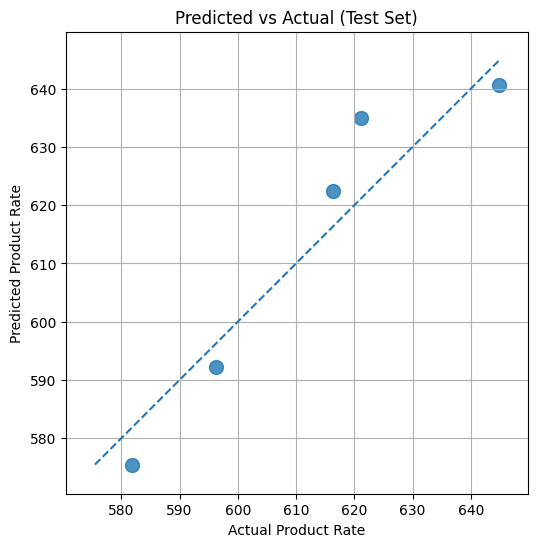

In [120]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, s=100, alpha=0.8)

# Perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Product Rate")
plt.ylabel("Predicted Product Rate")
plt.title("Predicted vs Actual (Test Set)")
plt.grid(True)

plt.xlim(min_val - 5, max_val + 5)
plt.ylim(min_val - 5, max_val + 5)

plt.gca().set_aspect('equal', adjustable='box')

plt.show()

The predicted versus actual plot demonstrates reasonable alignment with the 1:1 reference line, indicating that the Random Forest model captures a substantial proportion of productivity variability across batches. Most predictions lie close to the ideal line, although the highest productivity batch is moderately underpredicted, suggesting mild regression toward the mean. This behaviour is typical of ensemble tree models trained on relatively small datasets. Overall, the model exhibits stable generalisation performance without evidence of systematic bias.

Residuals Vs Pred

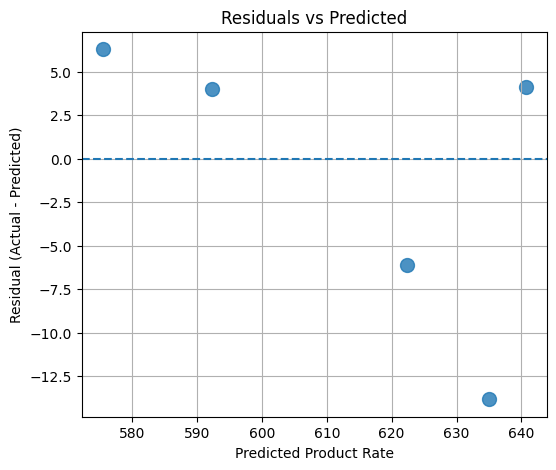

In [122]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, s=100, alpha=0.8)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Product Rate")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.grid(True)

plt.show()

Residuals are distributed around zero without clear structural pattern, indicating that the model does not exhibit strong systematic bias across the prediction range.

In [123]:
import pandas as pd

pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [rmse, mae, r2]
})

,Metric,Value
0,RMSE,7.775879
1,MAE,6.891132
2,R²,0.870760


### **Task 6**

Use the developed model to **predict the “missing” yield rate**.

### **Task 7**

Present the work in a **video presentation**.

- Evaluation focuses on **content**, not production quality.
- Audio commentary over slides is acceptable and must be **in your own voice**.
- All external resources and literature must be **accurately cited**.
- The presentation should combine **audio, visual, and textual elements** appropriately.

### **Task 8**


Summarise the case study in a **one-page infographic** that includes:
- Key results  
- Assumptions  
- Conclusions  

Guidelines:
- Follow **Data Visualization principles from Semester 1**
- Design for **A4 size**
- Minimum font size: **10 pt**
- The infographic should tell a **clear, coherent story**